In [66]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st

### Lectura de datos

In [67]:
ice_raw = pd.read_csv('/datasets/games.csv')
ice_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [68]:
ice = ice_raw.copy()
ice.sample(3)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
11395,Wildlife Park 3,PC,2011.0,Simulation,0.00,0.07,0.0,0.01,NaN,tbd,NaN
4443,TimeSplitters 2,GC,2002.0,Shooter,0.34,0.09,0.0,0.01,88.0,9,T
14064,Sid Meier's Railroads!,PC,2006.0,Simulation,0.01,0.03,0.0,0.00,NaN,NaN,NaN


### Validación y depuración de datos

In [69]:
rename_columns = []
for column in ice.columns:
    new_names = column.lower()
    rename_columns.append(new_names)
ice.columns=rename_columns

ice.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [70]:
ice['name'] = ice['name'].astype('string')
ice[['platform','genre','rating']]= ice[['platform','genre','rating']].astype('category')
ice['year_of_release'] = ice['year_of_release'].astype('Int64')
ice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  string  
 1   platform         16715 non-null  category
 2   year_of_release  16446 non-null  Int64   
 3   genre            16713 non-null  category
 4   na_sales         16715 non-null  float64 
 5   eu_sales         16715 non-null  float64 
 6   jp_sales         16715 non-null  float64 
 7   other_sales      16715 non-null  float64 
 8   critic_score     8137 non-null   float64 
 9   user_score       10014 non-null  object  
 10  rating           9949 non-null   category
dtypes: Int64(1), category(3), float64(5), object(1), string(1)
memory usage: 1.1+ MB


Se cambio el tipo de datos de las columnas:

    -'name' se especifico que el tipo de datos es string, ya que puede tomar cualquier valor de cadena de texto
    -'platform', 'genre' y 'rating' se paso a category ya que se tratan de categorias/grupos especificos en cada columna
    -'year_of_release' se especifico como entero(int) ya que se trata de años y al no tener mes ni dia, seria innecesario pasarlo a datetime, es conveniente que este como entero para hacer analisis

##### Duplicados

In [71]:
ice.duplicated().sum()

0

In [72]:
ice.duplicated(subset=['name','platform','year_of_release']).sum()


2

In [73]:
ice[ice.duplicated(subset=['name','platform','year_of_release'],keep=False)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,Madden NFL 13,PS3,2012,Sports,2.11,0.22,0.00,0.23,83.0,5.5,E
659,<NA>,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,<NA>,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN
16230,Madden NFL 13,PS3,2012,Sports,0.00,0.01,0.00,0.00,83.0,5.5,E


In [74]:
# ice_clean = ( ice .groupby(['name','platform','year_of_release','genre','rating'], as_index=False) .agg({ 'na_sales':'sum', 'eu_sales':'sum', 'jp_sales':'sum', 'other_sales':'sum', 'critic_score':'first', 'user_score':'first' }) )
# INTENTE UNIFICAR LOS DUPLICADOS SUMANDO LOS CENTAVOS DE UNA REGION QUE LE FALTABAN AL REGISTRO, PERO EL KERNEL MUERE CADA QUE LO CORRO, SEGUIRE ADELANTE YA QUE NO HAY DUPLICADOS EN SI

##### Ausentes

Tenemos valores ausente en las columnas:

    - name
    - year_of_release
    - genre
    - critic_score
    - user_score
    - rating

In [75]:
ice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  string  
 1   platform         16715 non-null  category
 2   year_of_release  16446 non-null  Int64   
 3   genre            16713 non-null  category
 4   na_sales         16715 non-null  float64 
 5   eu_sales         16715 non-null  float64 
 6   jp_sales         16715 non-null  float64 
 7   other_sales      16715 non-null  float64 
 8   critic_score     8137 non-null   float64 
 9   user_score       10014 non-null  object  
 10  rating           9949 non-null   category
dtypes: Int64(1), category(3), float64(5), object(1), string(1)
memory usage: 1.1+ MB


In [76]:
ice[ice['name'].isna()] 


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,<NA>,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,<NA>,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


se observa que los registros donde se tienen los valores faltantes de 'nombre' son los mismos que tienen faltantes de la columna genero, no tienen las columnas de score ni de rating, por lo que procederemos a eliminarlas...

In [77]:
ice = ice.dropna(subset=['name'])
ice.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  string  
 1   platform         16713 non-null  category
 2   year_of_release  16444 non-null  Int64   
 3   genre            16713 non-null  category
 4   na_sales         16713 non-null  float64 
 5   eu_sales         16713 non-null  float64 
 6   jp_sales         16713 non-null  float64 
 7   other_sales      16713 non-null  float64 
 8   critic_score     8137 non-null   float64 
 9   user_score       10014 non-null  object  
 10  rating           9949 non-null   category
dtypes: Int64(1), category(3), float64(5), object(1), string(1)
memory usage: 1.2+ MB


debido a que el objetivo del análisis es identificar patrones asociados al éxito comercial, estos registros no aportan información relevante y representan una fracción insignificante del conjunto de datos.

In [78]:
ice['user_score']=ice['user_score'].replace('tbd',pd.NA)
ice['user_score'] = pd.to_numeric(ice['user_score'], errors='coerce')
ice.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  string  
 1   platform         16713 non-null  category
 2   year_of_release  16444 non-null  Int64   
 3   genre            16713 non-null  category
 4   na_sales         16713 non-null  float64 
 5   eu_sales         16713 non-null  float64 
 6   jp_sales         16713 non-null  float64 
 7   other_sales      16713 non-null  float64 
 8   critic_score     8137 non-null   float64 
 9   user_score       7590 non-null   float64 
 10  rating           9949 non-null   category
dtypes: Int64(1), category(3), float64(6), string(1)
memory usage: 1.2 MB


In [79]:
ice['rating'] = ice['rating'].cat.add_categories('Unknown')
ice['rating'] = ice['rating'].fillna('Unknown')
ice.sample()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
5155,Batman: Arkham City,WiiU,2012,Action,0.16,0.18,0.0,0.03,NaN,NaN,Unknown


    Para las columnas:
    - year_of_release
    - critic_score
    - user_score
    
Se dejaron los valores ausentes en N/A, la primera (del año) no tiene sentido rellenarlos con la media o mediana ya que se trata del año de lazamiento, rellenarlos distorcionaria la informacion 

Para las columnas de score, el valor ausente se interpreta que simplemente no tienen un review, sea de criticos o de usuarios, entonces el N/A nos esta diciendo algo en estos casos; en el caso de la columna user_score se cambiaron los valores de tbd a NA, ya que tbd no nos dice algo relevante de las evaluaciones por usuario y NA es simplemente que aun no se tiene un review

    Para la columna 'rating':
Se creo la categoria 'unknown' para los datos ausentes, esto es mas util al hacer analisis categoricos en un futuro


In [80]:

ice['total_sales'] = (ice['na_sales']+ice['eu_sales']+ice['jp_sales']+ice['other_sales'])
ice.sample(4)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
14175,Challenge Me: Word Puzzles,DS,2011,Puzzle,0.03,0.00,0.00,0.00,NaN,NaN,E10+,0.03
2890,Dynasty Warriors 6,PS3,2007,Action,0.18,0.07,0.41,0.04,59.0,7.3,T,0.70
7549,Enchanted Arms,PS3,2007,Role-Playing,0.17,0.01,0.00,0.02,64.0,5.9,T,0.20
7695,Aikatsu! Cinderella Lesson,3DS,2012,Role-Playing,0.00,0.00,0.20,0.00,NaN,NaN,Unknown,0.20


### Analisis de datos

##### Juegos lanzados por año

In [81]:
ice['year_of_release'].value_counts().sort_index()

1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64

Se observa que hay un significativo crecimiento progresivo a partir del año 1994 pero fue hasta el 2000 que hubo un crecimiento significativamente importante y estable hasta el año 2011, del 2011 al 2016 descendio. 

Por lo anterior y tomando en cuenta el contexto tecnologico, lo conveniente sería trabajar con una parte de la base de datos, que contenga los datos a partir del año 2000 hasta el 2016.

##### Variacion de ventas por plataforma

In [82]:
platform_sales = ice.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
platform_sales.head(10)

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64

In [83]:
platform_year_sales = (ice.groupby(['year_of_release','platform'])['total_sales'].sum().reset_index())
platform_year_sales.sample(5)

,year_of_release,platform,total_sales
371,1991,XOne,0.0
713,2003,2600,0.0
1079,2014,WS,0.0
167,1985,NG,0.0
678,2001,WiiU,0.0


In [84]:
top_platform = platform_sales.head(5).index
filtered = platform_year_sales[platform_year_sales['platform'].isin(top_platform)].copy()
filtered.sample(6)

,year_of_release,platform,total_sales
90,1982,X360,0.0
264,1988,PS2,0.0
221,1987,DS,0.0
233,1987,PS2,0.0
462,1994,X360,0.0
47,1981,PS2,0.0


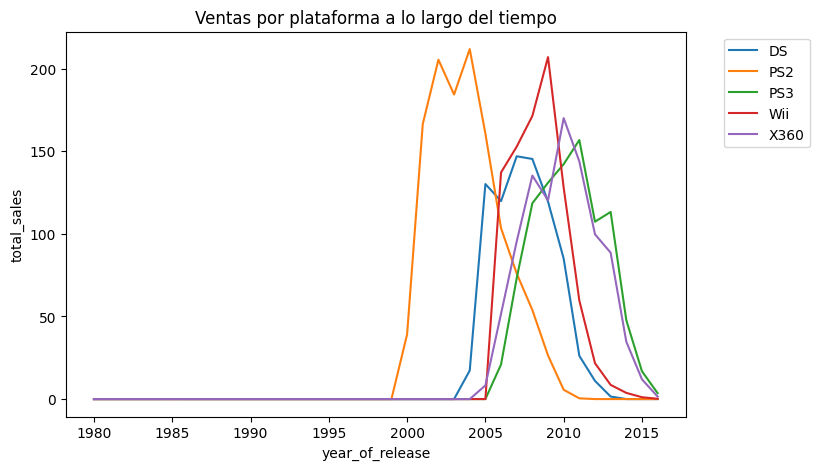

In [85]:
filtered['platform'] = filtered['platform'].cat.remove_unused_categories()
plt.figure(figsize=(8,5))
sns.lineplot(data=filtered,
             x='year_of_release',
             y='total_sales',
             hue='platform')

plt.title('Ventas por plataforma a lo largo del tiempo')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


En el grafico anterior, se observa que las plataformas que solian ser populares pero que ahora no tienen ventas son:

    - PS2
    - DS
    - Wii

Asimismo, se puede observar que suelen alcanzar su pico a los 3-4 años despues de su lanzamiento y su promedio de vida en el mercado es al rededor de los 8-10 años aproximadamente

In [86]:
last_year = ice['year_of_release'].max()

recent_sales = (platform_year_sales[platform_year_sales['year_of_release'] >= last_year - 2])
recent_sales.sample(5)

,year_of_release,platform,total_sales
1084,2014,XOne,54.07
1111,2015,Wii,1.14
1081,2014,WiiU,22.03
1137,2016,SAT,0.00
1089,2015,DS,0.00


In [87]:
recent_sales.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform
PS4     288.15
XOne    140.36
3DS      86.68
PS3      68.18
X360     48.22
WiiU     42.98
PC       27.05
PSV      22.40
Wii       5.07
PSP       0.36
XB        0.00
WS        0.00
TG16      0.00
SNES      0.00
SCD       0.00
SAT       0.00
2600      0.00
PS2       0.00
3DO       0.00
PCFX      0.00
NG        0.00
NES       0.00
N64       0.00
GG        0.00
GEN       0.00
GC        0.00
GBA       0.00
GB        0.00
DS        0.00
DC        0.00
PS        0.00
Name: total_sales, dtype: float64

In [88]:
platform_life = (ice.groupby('platform')['year_of_release'].agg(['min','max']).reset_index())
platform_life['lifespan'] = (platform_life['max'] - platform_life['min'])
platform_life.sort_values('lifespan',ascending=False)


,platform,min,max,lifespan
13,PC,1985,2016,31
4,DS,1985,2013,28
5,GB,1988,2001,13
28,X360,2005,2016,11
19,PSP,2004,2015,11
16,PS2,2000,2011,11
11,NES,1983,1994,11
3,DC,1998,2008,10
26,Wii,2006,2016,10
17,PS3,2006,2016,10


Las plataformas presentan ciclos de vida definidos. Generalmente tardan entre 3 y 5 años en alcanzar su punto máximo de ventas y permanecen activas alrededor de 8 a 12 años. Las nuevas generaciones emergen antes de que las anteriores desaparezcan por completo.

Teniendo en cuenta el grafico y el contexto mas general, para modelar 2017, se utilizaran los datos del 2005 al 2016, ya que representan el mercado contemporáneo de videojuegos, incluyendo generaciones de consolas comparables y patrones de consumo más recientes.

#### Datos del 2005 al 2016

In [89]:
ice_recent = ice[(ice['year_of_release']>=2005) & (ice['year_of_release']<=2016)].copy()
ice_recent['year_of_release'].min()

2005

In [90]:
platform_sales_ok = (ice_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index())
platform_sales_ok.head(10)

,platform,total_sales
0,X360,961.24
1,PS3,931.34
2,Wii,891.18
3,DS,785.49
4,PS2,426.46
5,PS4,314.14
6,PSP,282.47
7,3DS,257.81
8,PC,167.79
9,XOne,159.32


##### Plataformas relevantes

Las 3 plataformas que son lideres en ventas del 2005 al 2016 son:

    - X360
    - PS3
    - Wii
    

In [91]:
platform_year_ok = (ice_recent.groupby(['year_of_release','platform'])['total_sales'].sum().reset_index())

In [92]:
platform_year_ok[platform_year_ok['year_of_release'] ==2016].sort_values('total_sales', ascending=False)


,year_of_release,platform,total_sales
359,2016,PS4,69.25
371,2016,XOne,26.15
343,2016,3DS,15.14
354,2016,PC,5.25
368,2016,WiiU,4.60
361,2016,PSV,4.25
358,2016,PS3,3.60
369,2016,X360,1.52
367,2016,Wii,0.18
370,2016,XB,0.00


Durante el período 2005–2016, las plataformas con mayores ventas acumuladas fueron X360, PS3 y Wii. Sin embargo, su comportamiento muestra una fuerte disminución después de 2012, sobretodo para el Wii, lo que indica el fin de su ciclo de vida. 

Por otro lado, PS4 y XOne presentan una tendencia creciente hacia 2016, lo que sugiere que son plataformas con mayor potencial de rentabilidad para 2017.

In [93]:
platform_counts_ok = ice_recent['platform'].value_counts()

top_platforms_ok = platform_counts_ok[platform_counts_ok > 100].index

filtered_ok = ice_recent[ice_recent['platform'].isin(top_platforms_ok)].copy()

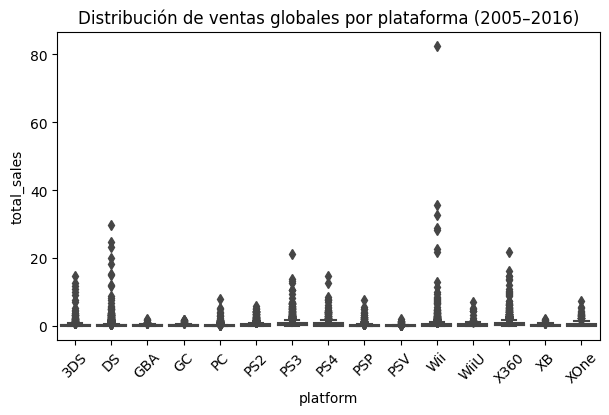

In [94]:

filtered_ok['platform'] = filtered_ok['platform'].cat.remove_unused_categories()
plt.figure(figsize=(7,4))
sns.boxplot(
    data=filtered_ok,
    x='platform',
    y='total_sales'
)

plt.xticks(rotation=45)
plt.title('Distribución de ventas globales por plataforma (2005–2016)')
plt.show()


In [95]:

filtered_ok.groupby('platform')['total_sales'].mean().round(2).sort_values(ascending=False)

platform
PS4     0.80
X360    0.78
PS3     0.71
Wii     0.69
XOne    0.65
WiiU    0.56
3DS     0.50
PS2     0.40
DS      0.37
GC      0.28
GBA     0.24
PSP     0.24
XB      0.24
PC      0.21
PSV     0.13
Name: total_sales, dtype: float64

In [96]:
filtered_ok.groupby('platform')['total_sales'].median().sort_values(ascending=False)

platform
X360    0.28
PS3     0.28
WiiU    0.22
XOne    0.22
PS4     0.20
Wii     0.19
PS2     0.16
GC      0.15
3DS     0.12
GBA     0.12
XB      0.12
DS      0.11
PSP     0.09
PC      0.05
PSV     0.05
Name: total_sales, dtype: float64

En el diagrama de caja se observan distribuciones asimétricas en todas las plataformas, con varios valores atípicos (que son juegos con ventas muy altas) 

La mayoría de los juegos presentan ventas relativamente bajas, mientras que unos pocos concentran gran parte del mercado. 

Se observan diferencias de dispersión entre plataformas, pero las medianas son relativamente similares, lo que sugiere que el éxito depende más de casos individuales (ciertos juegos) que del desempeño promedio de cada plataforma.

##### Reseñas vs ventas

In [97]:

popular_platform = (ice_recent[ice_recent['platform']== 'PS4']).copy()
popular_platform.head(2)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,Unknown,14.63
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62


In [98]:
popular_platform = popular_platform.dropna(
    subset=['user_score','critic_score','total_sales']
)

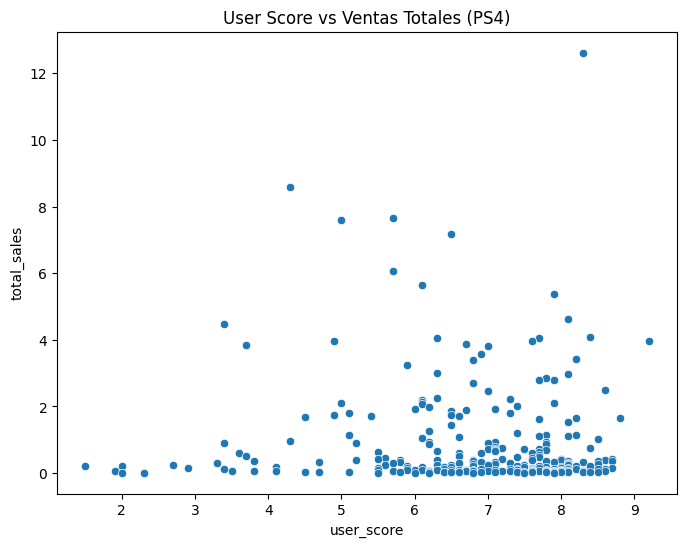

In [99]:

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=popular_platform,
    x='user_score',
    y='total_sales'
)

plt.title('User Score vs Ventas Totales (PS4)')
plt.show()


In [100]:
popular_platform['user_score'].corr(popular_platform['total_sales'])

-0.03362497596528878

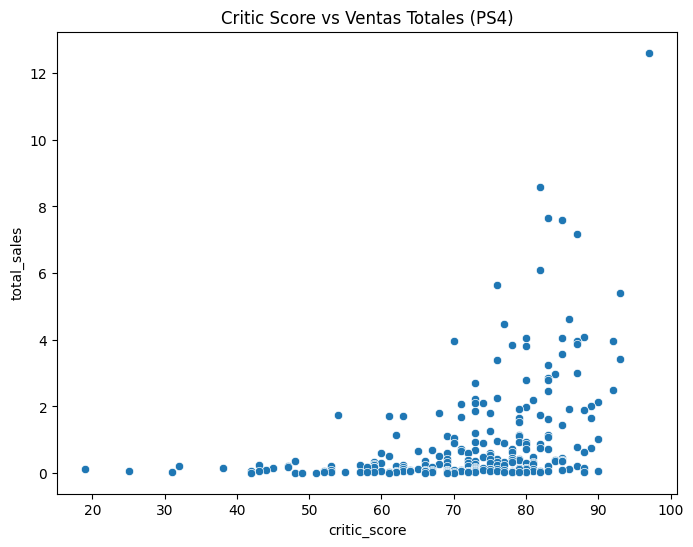

In [101]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=popular_platform,
    x='critic_score',
    y='total_sales'
)

plt.title('Critic Score vs Ventas Totales (PS4)')
plt.show()

In [102]:
popular_platform['critic_score'].corr(popular_platform['total_sales'])

0.40589480145836687

Se grafico y calculo la correlacion que existe entre las reseñas y las ventas totales de la plataforma PS4, que es la que tuvo mas ventas en el 2016

Se observa que existe una ligera correlacion con las reseñas de criticos, es  decir que si un juego tiene una buena reseña de criticos habra mas posibilidad de ventas

por otro lado, para el caso de las reseñas de usuarios, se observa que existe una relacion positiva debil

##### Juegos multiplataforma

In [103]:
games_count = ice_recent.groupby(ice_recent['name'])['platform'].nunique()
games_multiplatform = games_count[games_count>1].index

In [104]:
multiplatform = (ice_recent[ice_recent['name'].isin(games_multiplatform)]).copy()
sales_multiplatform = multiplatform.groupby(['name','platform'])['total_sales'].sum().reset_index()

In [105]:
pivot_table = sales_multiplatform.pivot(index='name',columns='platform',values='total_sales')
pivot_table.head(10)


platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
name,,,,,,,,,,,,,,,,,,,,,
Frozen: Olaf's Quest,0.0,0.0,0.59,0.0,0.51,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0
007: Quantum of Solace,0.0,0.0,0.00,0.0,0.13,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.65,0.0,1.48,0.00,0.0
11eyes: CrossOver,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.02,0.00,0.0
187: Ride or Die,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.06,0.0
2010 FIFA World Cup South Africa,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.43,0.0,0.85,0.00,0.0
2014 FIFA World Cup Brazil,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.43,0.00,0.0
25 to Life,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.17,0.0
3rd Super Robot Wars Z Jigoku Hen,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0
3rd Super Robot Wars Z: Tengoku-Hen,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0


En la tabla anterior se observa que las ventas de los videojuegos varían segun la plataforma. En la mayoria de los videojuegos alcanzan mas ventas en las plataformas líderes del mercado.

Esto sugiere que el desempeño comercial de los videojuegos depende de otros factores, como el mercado de la plataforma y las evaluaciones.

##### Juegos por género 

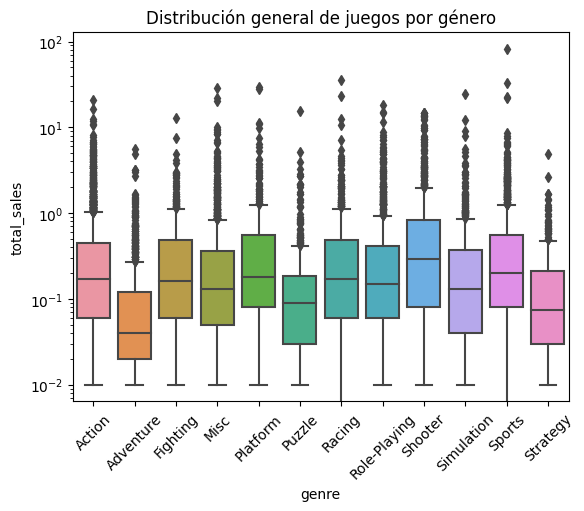

In [106]:
sns.boxplot(x='genre',
            y='total_sales',
            data=ice_recent)
plt.title('Distribución general de juegos por género')
plt.xticks(rotation=45)
plt.yscale('log')
plt.show()


In [107]:
genre_counts = ice_recent['genre'].value_counts()
print(genre_counts)

Action          2574
Sports          1383
Misc            1368
Role-Playing    1067
Adventure       1065
Shooter          833
Simulation       644
Racing           638
Fighting         456
Platform         423
Strategy         422
Puzzle           399
Name: genre, dtype: int64


In [108]:
genre_sales= ice_recent.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales.head(5)

genre
Action          1202.04
Sports           853.34
Shooter          758.56
Misc             615.83
Role-Playing     550.78
Name: total_sales, dtype: float64

Los generos que tienen mas ventas son:
    - Action
    - Sports
    - Shooter

Sin embargo, al analizar la distribución mediante diagramas de caja, se observa que Shooter y Sports presentan medianas más elevadas que Action (aunandole que Action tiene mas juegos), sugiere mayor rentabilidad promedio por título de los generos Shooter y Sports.

Por otro lado, los géneros que tienen ventas mas bajas y menor dispersión son: 
    - Adventure
    - Strategy
    - Puzzle
    
Esto indica que los géneros orientados a experiencias competitivas tienden a generar mayores ingresos.

#### Por regiones

In [109]:
topfive_platform = ice_recent.groupby(['platform'],observed=True)['total_sales'].sum().sort_values(ascending=False).head(5).index
print(topfive_platform)

CategoricalIndex(['X360', 'PS3', 'Wii', 'DS', 'PS2'], categories=['2600', '3DO', '3DS', 'DC', 'DS', 'GB', 'GBA', 'GC', ...], ordered=False, name='platform', dtype='category')


In [110]:
top_data = (ice_recent[ice_recent['platform'].isin(topfive_platform)].copy())
top_data.sample(4)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
5773,Pandora's Tower,Wii,2011,Role-Playing,0.11,0.10,0.08,0.02,73.0,8.0,T,0.31
7037,Carnival Island,PS3,2011,Misc,0.13,0.06,0.00,0.04,66.0,5.2,E,0.23
7224,Ultimate Band,DS,2008,Misc,0.19,0.02,0.00,0.02,69.0,NaN,E,0.23
14409,Beastly,Wii,2011,Misc,0.03,0.00,0.00,0.00,NaN,NaN,E10+,0.03


In [111]:

platform_region_sales = top_data.groupby('platform',observed=True)[['na_sales','eu_sales','jp_sales']].sum()


In [112]:
cuotas_mercado = platform_region_sales / platform_region_sales.sum()
cuotas_mercado.head(5)

,na_sales,eu_sales,jp_sales
platform,,,
Wii,0.238054,0.229522,0.178594
DS,0.181879,0.163914,0.448185
X360,0.291285,0.238407,0.032172
PS3,0.190753,0.290732,0.207706
PS2,0.098029,0.077425,0.133344



Las cinco plataformas principales muestran diferencias en su distribución regional. 
En Norteamérica y Europa, las consolas que concentran la mayor parte del mercado son:

    - Wii
    - X360
    - PS3
    

Sin embargo, en Japón se observa una preferencia por plataformas de origen japonés, especialmente Nintendo, mientras que X360 cuenta con una participación significativamente menor. 

Esto sugiere que las preferencias regionales influyen considerablemente en la cuota de mercado de cada plataforma.

##### Generos principales por Region


In [116]:

top_na_genres = (ice_recent.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5))
top_na.head()


genre
Action          580.04
Sports          432.70
Shooter         400.96
Misc            311.82
Role-Playing    211.85
Name: na_sales, dtype: float64

In [114]:
top_eu_genres = (ice_recent.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5))
top_eu.head()

genre
Action     372.58
Sports     265.61
Shooter    248.07
Misc       167.09
Racing     129.05
Name: eu_sales, dtype: float64

In [115]:
top_jp_genres = ice_recent.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)
top_jp_genres.head()

genre
Role-Playing    179.60
Action          108.39
Misc             72.49
Sports           52.51
Platform         36.32
Name: jp_sales, dtype: float64

Los datos muestran que:

En Norteamérica y Europa tienen preferencias similares, con tendencia hacia juegos de acción, competitivos y de disparos.

El mercado japonés muestra una mayor preferencia por juegos de rol.

Esto indica que las estrategias de lanzamiento y marketing deberían adaptarse según la región, ya que un género altamente rentable en NA/EU no necesariamente tendrá el mismo desempeño en Japón.

##### Clasificaciones de ESRB por ventas

In [119]:
rating_region_sales = ice_recent.groupby('rating')[['na_sales','eu_sales','jp_sales']].sum()
rating_region_sales.head(10)

,na_sales,eu_sales,jp_sales
rating,,,
AO,1.26,0.61,0.00
E,873.10,508.71,147.33
E10+,343.02,181.92,39.05
EC,1.53,0.11,0.00
K-A,0.00,0.00,0.00
M,607.34,414.11,46.23
RP,0.00,0.03,0.00
T,479.08,258.17,91.32
Unknown,323.49,253.45,291.65


In [123]:
rating_cuota_merc = (rating_region_sales/rating_region_sales.sum()).round(2)

print(rating_cuota_merc)

         na_sales  eu_sales  jp_sales
rating                               
AO           0.00      0.00      0.00
E            0.33      0.31      0.24
E10+         0.13      0.11      0.06
EC           0.00      0.00      0.00
K-A          0.00      0.00      0.00
M            0.23      0.26      0.08
RP           0.00      0.00      0.00
T            0.18      0.16      0.15
Unknown      0.12      0.16      0.47


Clasificaciones:
    - E (Everyone)
    - M (Mature)
    - T (Teen)


En Norteamérica y Europa, las clasificaciones E y M tienen la mayor parte del mercado, lo que sugiere una distribución equilibrada entre juegos familiares y títulos para audiencias maduras.

En Japón, la categoría "Unknown" representa casi la mitad del mercado, posiblemente por las diferencias en los sistemas de clasificación (por ejemplo, el uso de CERO en lugar de ESRB)

por lo anterior, la clasificación ESRB parece influir en las ventas en Norteamérica y Europa, pero su impacto es menos claro en Japón

#### Hipotesis 1

    H0 = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

    H1 = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.

In [129]:

xone = ice_recent[(ice_recent['platform'] == 'XOne') & 
                  (ice_recent['user_score'].notna())]['user_score']

pc = ice_recent[(ice_recent['platform'] == 'PC') & 
                (ice_recent['user_score'].notna())]['user_score']
alpha = 0.05
result=st.ttest_ind(xone, pc, equal_var=False)
print('valor p:',result.pvalue)

if result.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No se rechaza h0")

valor p: 0.002348015535956376
Rechazamos la hipótesis nula


Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.

#### Hipotesis 2

     H0 = Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.

     H1 = Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [130]:
action = ice_recent[(ice_recent['genre'] == 'Action') & 
                  (ice_recent['user_score'].notna())]['user_score']

sports = ice_recent[(ice_recent['genre'] == 'Sports') & 
                (ice_recent['user_score'].notna())]['user_score']
alpha = 0.05
result2=st.ttest_ind(action, sports, equal_var=False)
print('valor p:',result.pvalue)

if result2.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No se rechaza h0")

valor p: 0.002348015535956376
Rechazamos la hipótesis nula



La hipotesis nula establece que los valores son iguales de lo que se esta comparando, la alternativa siempre establecera que son diferentes, entonces aqui se establecio que la media del user score es la igual para las plataformas Xone y PC

Criterio para probar las hipotesis:

    p-value < 0.05 → rechazamos H₀
    p-value ≥ 0.05 → no rechazamos H₀

Para probar las hipótesis se utilizó una prueba t para muestras independientes, ya que se comparan las medias de dos grupos distintos. Se tomo el alpha de 0.05, es decir que manejamos el 95% de confiabilidad en los resultados presentados

### Conclusion General



El éxito comercial que tienen los videojuegos dependen de una combinación de factores y no de una sola variable.

Se tienen mas ventas en plataformas líderes, los ciclos de vida de éstas son definidos (8 a 10 años), por lo que elegir una plataforma activa y con alta cuota de mercado es fundamental

asimismo, se debe considerar las preferencias de género que se tienen por region, ya que varían significativamente, en Norteamérica y Europa muestran patrones similares (Acción, deportes y disparos) pero en Japón existen diferencias claras debido a que prefieren juegos de Rol.

Las reseñas de criticos profesionales muestran una relación más consistente con las ventas que las calificaciones de usuarios, por lo que las evaluaciones de críticos puede influir en las ventas. En cuanto a las clasificaciones por edad (rating(ESRB)) parece impactar el mercado en Norteamérica y Europa, su impacto en Japón es menos concluyente.

Los datos indican que para tener mas posibilidades de éxito de videojuegos en 2017, es importante considerar la región para seleccionar las plataformas consolidadas así como enfocarse en géneros con alta demanda local